### Qustion 3: The majority vote


<span style="color: red; font-size: 30px;">A:</span>

We conclude that using the majority vote can be useful and increase the accuracy of choosing. 
The probability of correct choice by the majority will usually be so close to 1 if 
ecah member's choice precision is good enough. But if the personal precision was lower than 0.5, 
then it would be better to choose by one person not by the majority; becuase the more people vote
the more probability of choosing wrongly increases.

In [3]:
p = [0.7, 0.7, 0.3, 0.5, 0.5]
num_of_ones = [8, 10, 8, 9, 5]
num_of_zeros = [4, 2, 4, 3, 7]

for i in range(len(num_of_ones)):
    x = max(num_of_ones[i], num_of_zeros[i])
    y = min(num_of_ones[i], num_of_zeros[i])
    probability_of_correct_group_decision = ((p[i] ** x * (1 - p[i]) ** y) /
                                             (p[i] ** x * (1 - p[i]) ** y + (1 - p[i]) ** x * p[i] ** y))
    print(f"{probability_of_correct_group_decision:.3f}")

0.967
0.999
0.033
0.500
0.500


<span style="color: red; font-size: 30px;">B:</span>

First we import the needed modules.


In [4]:
import matplotlib.pyplot as plt
import numpy as np

Now we quantify the parameters.

In [5]:
num_of_voters = 12
num_of_simulations = 1000

Then we write the main simulation function which simulates the election as much as we've defined before.

In [6]:
import random
random.seed(467)
def choose_randomly(p):
    r = random.randint(1, 100)
    return r <= p*100

def calculate_accuracy(p, n, num_of_simulations):
    num_of_successful_simulations = 0

    for k in range(num_of_simulations):
        correct_option = 1
        wrong_option = 0
        num_of_correct_choices = 0
        
        # The better way: We randomize the correct option too!
        # correct_option = np.random.choice([1, 0])
        # wrong_option = 1 if correct_option == 0 else 0

        for i in range(n):
            choice = correct_option if choose_randomly(p) else wrong_option

            if choice == correct_option:
                num_of_correct_choices += 1

        if num_of_correct_choices > n / 2:
            num_of_successful_simulations += 1

    return num_of_successful_simulations / num_of_simulations

Now we create the p values list and calculate the accuracy for each of them.

In [7]:
p_variable = np.arange(0, 1.1, 0.1)
accuracies = []

for i in range(p_variable.size):
    accuracies.append(calculate_accuracy(p_variable[i], num_of_voters, num_of_simulations))

Let's plot the results!

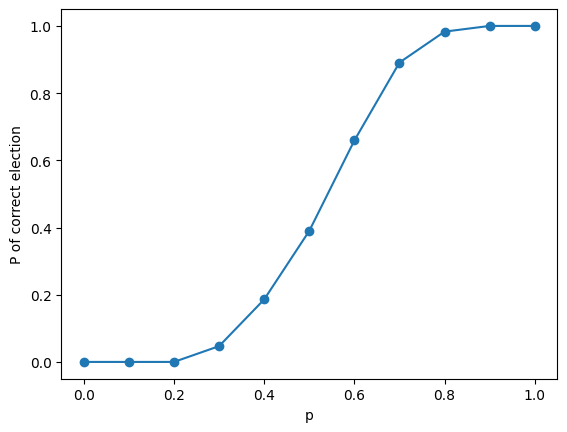

In [8]:
plt.plot(p_variable, accuracies, '-o')
plt.xlabel("p")
plt.ylabel("P of correct election")
plt.show()

<span style="color: red; font-size: 30px;">C:</span>

Using a loop, we find the optimal p.

In [9]:
p_variable = np.arange(0, 1, 0.1)

for i in range(p_variable.size):
    if calculate_accuracy(p_variable[i], num_of_voters, num_of_simulations) == 1:
        print(p_variable[i])
        break

0.9


<span style="color: red; font-size: 30px;">D:</span>

A beautiful heatmap :)

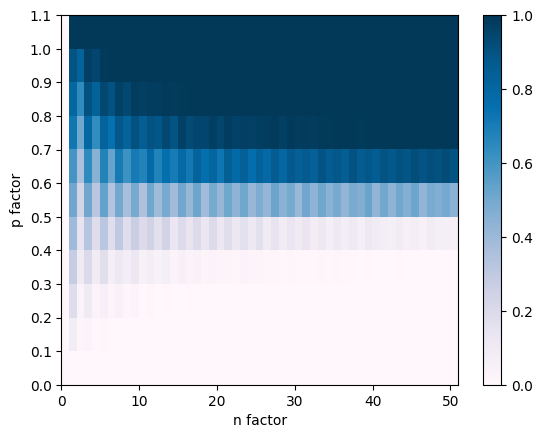

In [10]:
accuracies = np.ones((11, 51))
num_of_simulations = 1000

for p in range(0, 11):
    for n in range(0, 51):
        accuracies[10 - p][n] = calculate_accuracy(p/10, n, num_of_simulations)

plt.imshow(accuracies, cmap='PuBu', interpolation='nearest', extent = (0, 51, 0, 1), aspect = 'auto')
plt.yticks(ticks=np.linspace(0, 1, 12), labels=[f'{i/10:.1f}' for i in range(12)])
plt.ylabel("p factor")
plt.xlabel("n factor")
plt.colorbar()
plt.show()